# AI & ML Internship – Task 2  
## Feature Engineering, Model Optimization & Performance Comparison

In this task, we use the California Housing Dataset to:
- Perform data preprocessing
- Apply feature scaling
- Train multiple regression models
- Compare model performance using RMSE and R² Score

In [8]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Step 1: Load the Dataset

We load the California Housing dataset using scikit-learn.
This dataset contains housing features and target house prices.

In [9]:
# Load dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Convert to DataFrame for better understanding
df = pd.DataFrame(X, columns=housing.feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 2: Train-Test Split

We split the dataset into:
- 80% Training Data
- 20% Testing Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 3: Feature Scaling

We apply StandardScaler to normalize the feature values.
Feature scaling improves model performance.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 4: Apply Machine Learning Models

We train the following models:
- Linear Regression
- Ridge Regression
- Decision Tree Regressor

In [12]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

## Step 5: Model Evaluation

We evaluate models using:
- RMSE (Root Mean Square Error)
- R² Score

In [13]:
def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} Results:")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}")
    print("----------------------------")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)
evaluate_model("Decision Tree", y_test, y_pred_dt)

Linear Regression Results:
RMSE: 0.7455813830127763
R2 Score: 0.5757877060324508
----------------------------
Ridge Regression Results:
RMSE: 0.745556744281478
R2 Score: 0.5758157428913683
----------------------------
Decision Tree Results:
RMSE: 0.7028289572288925
R2 Score: 0.6230424613065773
----------------------------


## Step 6: Visualization

We plot Actual vs Predicted values for Linear Regression.

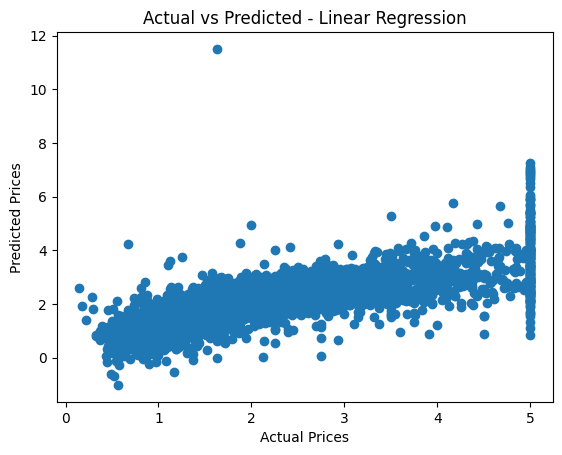

In [14]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()